In [3]:
import mne
import pandas as pd
import os
import numpy as np


import matplotlib.pyplot as plt


import seaborn as sns
from tqdm import tqdm  # 進捗表示用

import pickle
from pathlib import Path


In [ ]:
TIKZ_OUTPUT_DIR = Path('tikz')
OPENNEURO_TIKZ_DIR = TIKZ_OUTPUT_DIR / 'openNeuro'
OPENNEURO_ASSET_DIR = OPENNEURO_TIKZ_DIR / 'assets'


def write_tikz(output_tex_path, tikz_code):
    output_tex_path = Path(output_tex_path)
    output_tex_path.parent.mkdir(parents=True, exist_ok=True)
    output_tex_path.write_text(tikz_code, encoding='utf-8')


def tex_escape(value):
    text = str(value)
    replacements = {
        '\\': r'\textbackslash{}',
        '&': r'\&',
        '%': r'\%',
        '$': r'\$',
        '#': r'\#',
        '_': r'\_',
        '{': r'\{',
        '}': r'\}',
        '~': r'\textasciitilde{}',
        '^': r'\textasciicircum{}',
    }
    return ''.join(replacements.get(char, char) for char in text)


def save_openneuro_heatmap_tikz(
    fragility,
    times,
    onset_time,
    channel_names,
    output_tex_path,
    image_path,
    colorbar_label='Neural Fragility',
    include_title=False,
):
    output_tex_path = Path(output_tex_path)
    image_path = Path(image_path)
    colorbar_path = image_path.with_name(image_path.stem + '_colorbar.png')
    output_tex_path.parent.mkdir(parents=True, exist_ok=True)
    image_path.parent.mkdir(parents=True, exist_ok=True)

    fragility = np.asarray(fragility)
    n_channels, n_windows = fragility.shape
    onset_idx = int(np.argmin(np.abs(times - onset_time)))

    # Keep dense heatmap pixels as compact raster assets and put axes/labels in TikZ.
    plt.imsave(image_path, fragility, cmap='turbo', vmin=0.0, vmax=1.0, origin='upper')
    colorbar_gradient = np.linspace(1.0, 0.0, 256).reshape(256, 1)
    plt.imsave(colorbar_path, colorbar_gradient, cmap='turbo', vmin=0.0, vmax=1.0)

    n_xticks = 20
    x_tick_indices = np.linspace(0, n_windows - 1, n_xticks, dtype=int)
    x_ticks = ','.join(str(int(i)) for i in x_tick_indices)
    x_tick_labels = ','.join(tex_escape(f'{times[i] - onset_time:.1f}') for i in x_tick_indices)

    y_step = max(1, int(np.ceil(n_channels / 30)))
    y_tick_indices = np.arange(0, n_channels, y_step)
    y_ticks = ','.join(str(int(i)) for i in y_tick_indices)
    y_tick_labels = ','.join(tex_escape(channel_names[i]) for i in y_tick_indices)

    rel_image_path = image_path.relative_to(output_tex_path.parent)
    rel_colorbar_path = colorbar_path.relative_to(output_tex_path.parent)
    title_option = 'title={Neural Fragility Heatmap},' if include_title else ''

    tikz_code = f"""\\begin{{tikzpicture}}
\\begin{{axis}}[
    name=heatmap,
    width=15cm,
    height=10cm,
    xmin=-0.5,
    xmax={n_windows - 0.5},
    ymin={n_channels - 0.5},
    ymax=-0.5,
    xlabel={{Time relative to Seizure Onset (s)}},
    ylabel={{Channels}},
    {title_option}
    xtick={{{x_ticks}}},
    xticklabels={{{x_tick_labels}}},
    x tick label style={{rotate=45, anchor=east}},
    ytick={{{y_ticks}}},
    yticklabels={{{y_tick_labels}}},
    y tick label style={{font=\\scriptsize}},
    enlargelimits=false,
    axis on top,
]
\\addplot graphics [
    xmin=-0.5,
    xmax={n_windows - 0.5},
    ymin={n_channels - 0.5},
    ymax=-0.5,
] {{{rel_image_path.as_posix()}}};
\\draw[white, dashed, line width=1.2pt] (axis cs:{onset_idx},-0.5) -- (axis cs:{onset_idx},{n_channels - 0.5});
\\end{{axis}}
\\begin{{axis}}[
    at={{(heatmap.outer north east)}},
    anchor=outer north west,
    xshift=0.35cm,
    width=0.75cm,
    height=10cm,
    xmin=0,
    xmax=1,
    ymin=0,
    ymax=1,
    xtick=\\empty,
    ytick={{0,0.25,0.5,0.75,1}},
    ylabel={{{tex_escape(colorbar_label)}}},
    ylabel style={{font=\\small}},
    tick label style={{font=\\scriptsize}},
    enlargelimits=false,
    axis on top,
]
\\addplot graphics [xmin=0, xmax=1, ymin=0, ymax=1] {{{rel_colorbar_path.as_posix()}}};
\\end{{axis}}
\\end{{tikzpicture}}
"""
    write_tikz(output_tex_path, tikz_code)


In [11]:
# --- ファイルパスの設定 ---
# 手元のディレクトリ構造に合わせて変更してください
data_dir = './data'  # データがあるフォルダ
subject_prefix = 'sub-pt01_ses-presurgery_task-ictal_acq-ecog_run-01'
vhdr_file = os.path.join(data_dir, f'{subject_prefix}_ieeg.vhdr')
events_file = os.path.join(data_dir, f'{subject_prefix}_events.tsv')
channels_file = os.path.join(data_dir, f'{subject_prefix}_channels.tsv')

# --- 1. イベントファイルからOnset時間を取得 ---
df_events = pd.read_csv(events_file, sep='\t')
onset_rows = df_events[df_events['trial_type'].str.contains('onset', case=False, na=False)]

if onset_rows.empty:
    raise ValueError("Onset event not found in events.tsv")

seizure_onset_time = onset_rows.iloc[0]['onset']
print(f"Detected Onset: {seizure_onset_time} sec")


# --- 2. channels.tsv から不良チャンネル (status='bad') を特定 ---
# ファイルを読み込む
df_channels = pd.read_csv(channels_file, sep='\t')

# 'status' 列が 'bad' の行を抽出（大文字小文字を区別しないように lower() を使用）
# データセットによっては 'status_description' などの列名の場合もあるため確認が必要です
bad_channels_list = []
if 'status' in df_channels.columns:
    bad_channels_df = df_channels[df_channels['status'].str.lower() == 'bad']
    bad_channels_list = bad_channels_df['name'].tolist()
    print(f"Found {len(bad_channels_list)} bad channels in tsv: {bad_channels_list}")
else:
    print("Warning: 'status' column not found in channels.tsv")

# # さらに, 36番目と37番目のチャンネルも不良チャンネルとして追加
# additional_bad_channels = []
# if len(df_channels) > 36:
#     additional_bad_channels.append(df_channels.iloc[36]['name'])
# if len(df_channels) > 37:
#     additional_bad_channels.append(df_channels.iloc[37]['name'])

# bad_channels_list.extend(additional_bad_channels)
# if additional_bad_channels:
#     print(f"Additionally marking channels as bad: {additional_bad_channels}")


# --- 3. データの読み込みとクロッピング ---
tmin = seizure_onset_time - 60.0
tmax = seizure_onset_time + 60.0

# メタデータのみ先に読み込み
raw = mne.io.read_raw_brainvision(vhdr_file, preload=False, verbose=False)

# 時間範囲の調整
start_crop = max(0, tmin)
end_crop = min(raw.times[-1], tmax)

# データをロード
raw_cropped = raw.crop(tmin=start_crop, tmax=end_crop)
raw_cropped.load_data()


# --- 4. 不良チャンネルの削除 (Drop Bad Channels) ---
# Rawデータに実際に存在するチャンネルのみを対象とする（念のため）
channels_to_drop = [ch for ch in bad_channels_list if ch in raw_cropped.ch_names]

if channels_to_drop:
    print(f"Dropping {len(channels_to_drop)} channels from data.")
    raw_cropped.drop_channels(channels_to_drop)
else:
    print("No bad channels to drop.")

# 結果の確認
print(f"Data loaded successfully. Shape: {raw_cropped.get_data().shape} (Channels, TimePoints)")

# 必要であれば情報を表示
print(raw_cropped.info)

Detected Onset: 75.95 sec
Found 14 bad channels in tsv: ['G5', 'G6', 'DC01', 'DC09', 'DC10', 'DC11', 'DC12', '$G11', '$G12', 'RQ1', 'RQ2', 'EKG1', 'EKG2', nan]
Reading 0 ... 120000  =      0.000 ...   120.000 secs...
Dropping 13 channels from data.
Data loaded successfully. Shape: (85, 120001) (Channels, TimePoints)
<Info | 7 non-empty values
 bads: []
 ch_names: G1, G2, G3, G4, G7, G8, G9, G10, G13, G14, G15, G16, G17, G18, ...
 chs: 85 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 500.0 Hz
 meas_date: 1920-07-24 19:35:19 UTC
 nchan: 85
 projs: []
 sfreq: 1000.0 Hz
>


In [12]:
# raw_cropped は前段のコードで読み込んだ MNE Rawオブジェクトとします

# --- 1. ノッチフィルタ (Notch Filter) ---
# 論文記述: "notch filtered at 60 Hz (with a cutoff window of 2 Hz)" [cite: 772]
# ノッチ幅を2Hzに設定して60Hzのノイズを除去します。
# 電源ノイズの高調波(120Hz, 180Hz...)も除去するのが一般的ですが、
# 論文には "at 60 Hz" とあるため、ここでは60Hzのみを対象とします。
raw_cropped.notch_filter(freqs=60, notch_widths=2.0)


# --- 2. バンドパスフィルタ (Band-pass Filter) ---
# 論文記述: "band-pass-filtered between 0.5 and the Nyquist frequency with a fourth-order Butterworth filter" 
# Nyquist周波数までのバンドパスは実質的にハイパスフィルタと同義です。
# MNEでButterworthフィルタを使用するため、method='iir' を指定します。

iir_params = dict(order=4, ftype='butter')
raw_cropped.filter(l_freq=0.5, h_freq=None, method='iir', iir_params=iir_params)
# 注: h_freq=None はNyquist周波数（上限なし）を意味します


# --- 3. 相関ノイズ除去 (Common Average Reference - CAR) ---
# 論文記述: "A common average reference was applied to remove any correlated noise." [cite: 775]
# 全電極の平均値を各電極から差し引くことで、コモンモードノイズを除去します。
# projection=False により、設定を即座にデータに適用します。
raw_cropped.set_eeg_reference(ref_channels='average', projection=False)


# --- 結果の確認 ---
print("Preprocessing complete.")
print(raw_cropped.info)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 58 - 62 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 58.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 58.25 Hz)
- Upper passband edge: 61.50 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 61.75 Hz)
- Filter length: 6601 samples (6.601 s)



Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.5 Hz

IIR filter parameters
---------------------
Butterworth highpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 8 (effective, after forward-backward)
- Cutoff at 0.50 Hz: -6.02 dB

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Preprocessing complete.
<Info | 8 non-empty values
 bads: []
 ch_names: G1, G2, G3, G4, G7, G8, G9, G10, G13, G14, G15, G16, G17, G18, ...
 chs: 85 EEG
 custom_ref_applied: True
 highpass: 0.5 Hz
 lowpass: 500.0 Hz
 meas_date: 1920-07-24 19:35:19 UTC
 nchan: 85
 projs: []
 sfreq: 1000.0 Hz
>


In [8]:
# raw_cropped.plot(scalings='auto', n_channels=20, title="Interactive Plot")

In [13]:
def create_sliding_windows(raw_data, window_size_ms=250, step_size_ms=125):
    """
    MNE Rawオブジェクトからスライディングウィンドウを作成します。
    
    Parameters:
    -----------
    raw_data : mne.io.Raw
        前処理済みのRawオブジェクト
    window_size_ms : float
        ウィンドウサイズ (ミリ秒)。論文に従いデフォルトは250ms。
    step_size_ms : float
        ステップサイズ (ミリ秒)。論文に従いデフォルトは125ms。
        
    Returns:
    --------
    windows : np.ndarray
        形状 (n_windows, n_channels, n_samples_per_window) の3次元配列
    window_times : np.ndarray
        各ウィンドウの中心時刻に対応する配列 (n_windows,)
    """
    # 1. サンプリング周波数の取得
    sfreq = raw_data.info['sfreq']
    
    # 2. ミリ秒をサンプル数に変換
    n_samples_window = int(window_size_ms * sfreq / 1000)
    n_samples_step = int(step_size_ms * sfreq / 1000)
    
    # 3. データの取得 (n_channels, n_times)
    data = raw_data.get_data()
    n_channels, n_times = data.shape
    
    # 4. ウィンドウ数の計算
    # 最後のウィンドウがデータ範囲を超えないように計算
    n_windows = (n_times - n_samples_window) // n_samples_step + 1
    
    if n_windows <= 0:
        raise ValueError("データ長がウィンドウサイズより短いため、分割できません。")

    print(f"Sampling Rate: {sfreq:.1f} Hz")
    print(f"Window samples: {n_samples_window}, Step samples: {n_samples_step}")
    print(f"Total windows: {n_windows}")

    # 5. ウィンドウ配列の作成
    # shape: (n_windows, n_channels, n_samples_window)
    window_list = []
    window_time_indices = [] # 各ウィンドウの開始時点のサンプルインデックス
    
    for i in range(n_windows):
        start_idx = i * n_samples_step
        end_idx = start_idx + n_samples_window
        
        # データの切り出し
        win_data = data[:, start_idx:end_idx]
        window_list.append(win_data)
        window_time_indices.append(start_idx)
    
    windows = np.array(window_list)
    
    # 6. 各ウィンドウの時間（秒）を計算
    # ここではウィンドウの「中心時刻」を代表時刻とします
    window_times = raw_data.times[window_time_indices] + (window_size_ms / 1000 / 2)
    
    return windows, window_times

# --- 実行 ---
# raw_cropped は前段の前処理済みデータを使用
windows, window_times = create_sliding_windows(raw_cropped, window_size_ms=250, step_size_ms=125)

print(f"Created windows shape: {windows.shape}")
# 出力例: (958, 88, 250) -> (ウィンドウ数, チャンネル数, 1ウィンドウあたりのサンプル数)

Sampling Rate: 1000.0 Hz
Window samples: 250, Step samples: 125
Total windows: 959
Created windows shape: (959, 85, 250)


In [14]:
def estimate_linear_models(windows, l2_lambda=1e-4):
    """
    各ウィンドウについて線形力学モデル x(t+1) = Ax(t) を推定します。
    
    Parameters:
    -----------
    windows : np.ndarray
        形状 (n_windows, n_channels, n_samples) のデータ
    l2_lambda : float
        Ridge回帰の正則化パラメータ。論文では 10 * 10^-5 = 0.0001 と記述。
        
    Returns:
    --------
    A_matrices : np.ndarray
        推定されたA行列の配列。形状 (n_windows, n_channels, n_channels)
    """
    n_windows, n_channels, n_samples = windows.shape
    
    # 推定されたA行列を格納する配列
    A_matrices = np.zeros((n_windows, n_channels, n_channels))
    
    print(f"Estimating linear models for {n_windows} windows...")
    print(f"Regularization lambda: {l2_lambda}")

    # 各ウィンドウごとに処理
    for i in tqdm(range(n_windows)):
        # 1つのウィンドウデータ (n_channels, n_samples)
        W = windows[i]
        
        # X(t): 時刻 0 から N-1 まで
        X_t = W[:, :-1]
        
        # X(t+1): 時刻 1 から N まで
        X_t1 = W[:, 1:]
        
        # --- Ridge回帰によるAの推定 ---
        # 公式: A = X(t+1) * X(t).T * (X(t) * X(t).T + lambda * I)^-1
        
        # 1. 共分散行列のような項 X(t)X(t)^T を計算 (n_channels, n_channels)
        Xt_XtT = X_t @ X_t.T
        
        # 2. 正則化項を加える
        regularization = l2_lambda * np.eye(n_channels)
        inverse_term = np.linalg.pinv(Xt_XtT + regularization)
        
        # 3. X(t+1)X(t)^T を計算
        Xt1_XtT = X_t1 @ X_t.T
        
        # 4. A行列の計算
        A_hat = Xt1_XtT @ inverse_term
        
        # 結果を格納
        A_matrices[i] = A_hat
        
    return A_matrices

# --- 実行 ---
# windows は前段のスライディングウィンドウ処理の結果を使用
# 論文のパラメータ 10*10^-5 に基づき lambda=0.0001 を設定
A_mats = estimate_linear_models(windows, l2_lambda=0.0001)

print(f"Estimated A matrices shape: {A_mats.shape}")
# 出力例: (958, 88, 88) -> (ウィンドウ数, チャネル数, チャネル数)

Estimating linear models for 959 windows...
Regularization lambda: 0.0001


100%|██████████| 959/959 [00:00<00:00, 1536.15it/s]

Estimated A matrices shape: (959, 85, 85)


Evaluating fitting error for 959 windows...


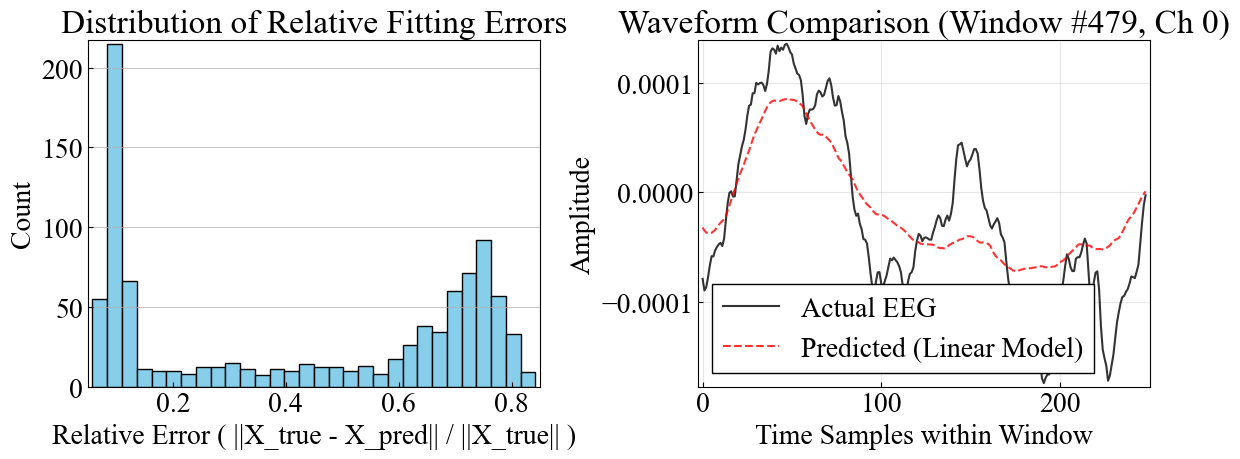

=== Fitting Error Statistics ===
Mean Relative Error: 0.4315
Median Relative Error: 0.4797
Max Relative Error: 0.8423
------------------------------


In [15]:
import numpy as np
import matplotlib.pyplot as plt

def evaluate_model_fitting(windows, A_matrices):
    """
    線形モデルのフィッティング誤差を評価・可視化します。
    
    Parameters:
    -----------
    windows : np.ndarray
        形状 (n_windows, n_channels, n_samples) の実データ
    A_matrices : np.ndarray
        形状 (n_windows, n_channels, n_channels) の推定モデル
    """
    n_windows, n_channels, n_samples = windows.shape
    
    relative_errors = []
    
    # 比較用のサンプル波形を保存するためのリスト
    sample_true = None
    sample_pred = None
    sample_win_idx = n_windows // 2  # 真ん中のウィンドウをサンプルにする
    
    print(f"Evaluating fitting error for {n_windows} windows...")
    
    for i in range(n_windows):
        W = windows[i]
        A = A_matrices[i]
        
        # 実データ: x(t) と x(t+1)
        X_t = W[:, :-1]
        X_t1_true = W[:, 1:]
        
        # モデルによる予測: x(t+1) = A * x(t)
        X_t1_pred = A @ X_t
        
        # 誤差の計算 (フロベニウスノルム)
        diff = X_t1_true - X_t1_pred
        error_norm = np.linalg.norm(diff, 'fro')
        true_norm = np.linalg.norm(X_t1_true, 'fro')
        
        # 相対誤差 (Relative Error)
        # 0割りを防ぐための小さな値
        rel_error = error_norm / (true_norm + 1e-9)
        relative_errors.append(rel_error)
        
        # サンプル用に保存
        if i == sample_win_idx:
            sample_true = X_t1_true
            sample_pred = X_t1_pred

    relative_errors = np.array(relative_errors)
    
    # --- 結果の可視化 ---
    plt.figure(figsize=(12, 5))
    
    # 1. 誤差のヒストグラム
    plt.subplot(1, 2, 1)
    plt.hist(relative_errors, bins=30, color='skyblue', edgecolor='black')
    plt.title("Distribution of Relative Fitting Errors")
    plt.xlabel("Relative Error ( ||X_true - X_pred|| / ||X_true|| )")
    plt.ylabel("Count")
    plt.grid(axis='y', alpha=0.7)
    
    # 2. 波形の比較 (サンプルウィンドウの最初のチャネル)
    plt.subplot(1, 2, 2)
    # 最初のチャネルのみ表示
    ch_idx = 0 
    time_steps = np.arange(sample_true.shape[1])
    
    plt.plot(time_steps, sample_true[ch_idx], label="Actual EEG", color='black', alpha=0.8, linewidth=1.5)
    plt.plot(time_steps, sample_pred[ch_idx], label="Predicted (Linear Model)", color='red', linestyle='--', alpha=0.8)
    
    plt.title(f"Waveform Comparison (Window #{sample_win_idx}, Ch {ch_idx})")
    plt.xlabel("Time Samples within Window")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 統計量の表示
    print(f"=== Fitting Error Statistics ===")
    print(f"Mean Relative Error: {np.mean(relative_errors):.4f}")
    print(f"Median Relative Error: {np.median(relative_errors):.4f}")
    print(f"Max Relative Error: {np.max(relative_errors):.4f}")
    print("-" * 30)

# --- 実行 ---
evaluate_model_fitting(windows, A_mats)

Stable A matrices: 959 / 959 (100.00%)


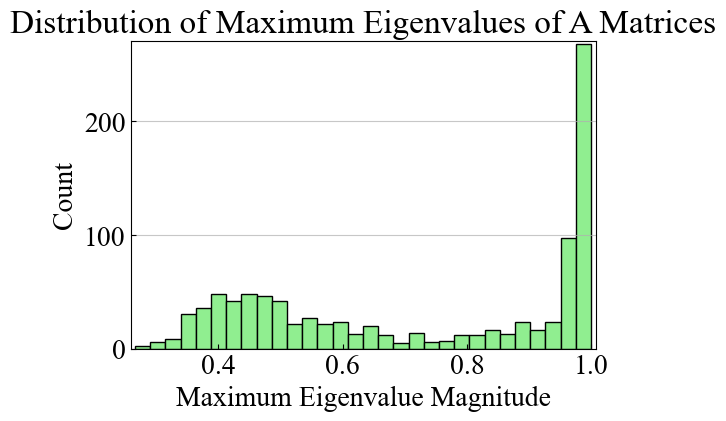

In [16]:
# 各行列が安定であるかどうかを判定する関数
def is_stable(A):
    """行列Aが安定かどうかを判定する関数。すべての固有値の絶対値が1以下であれば安定とみなす。"""
    eigenvalues = np.linalg.eigvals(A)
    return np.all(np.abs(eigenvalues) <= 1.0)

# A_mats が安定であるかどうかを確認
stability_results = [is_stable(A) for A in A_mats]
n_stable = sum(stability_results)
n_total = len(A_mats)
print(f"Stable A matrices: {n_stable} / {n_total} ({(n_stable / n_total) * 100:.2f}%)")

# 最大固有値の分布を見る
max_eigenvalues = [max(np.abs(np.linalg.eigvals(A))) for A in A_mats]
plt.figure(figsize=(6,4))
plt.hist(max_eigenvalues, bins=30, color='lightgreen', edgecolor='black')
plt.title("Distribution of Maximum Eigenvalues of A Matrices")
plt.xlabel("Maximum Eigenvalue Magnitude")
plt.ylabel("Count")
plt.grid(axis='y', alpha=0.7)
plt.show()

In [17]:
raw_cropped.ch_names

# raw_cropped.ch_names の数
n_channels = len(raw_cropped.ch_names)
n_channels

85

Calculating Neural Fragility for 85 channels x 959 windows...


100%|██████████| 959/959 [1:08:55<00:00,  4.31s/it]


ValueError: The number of FixedLocator locations (43), usually from a call to set_ticks, does not match the number of labels (85).

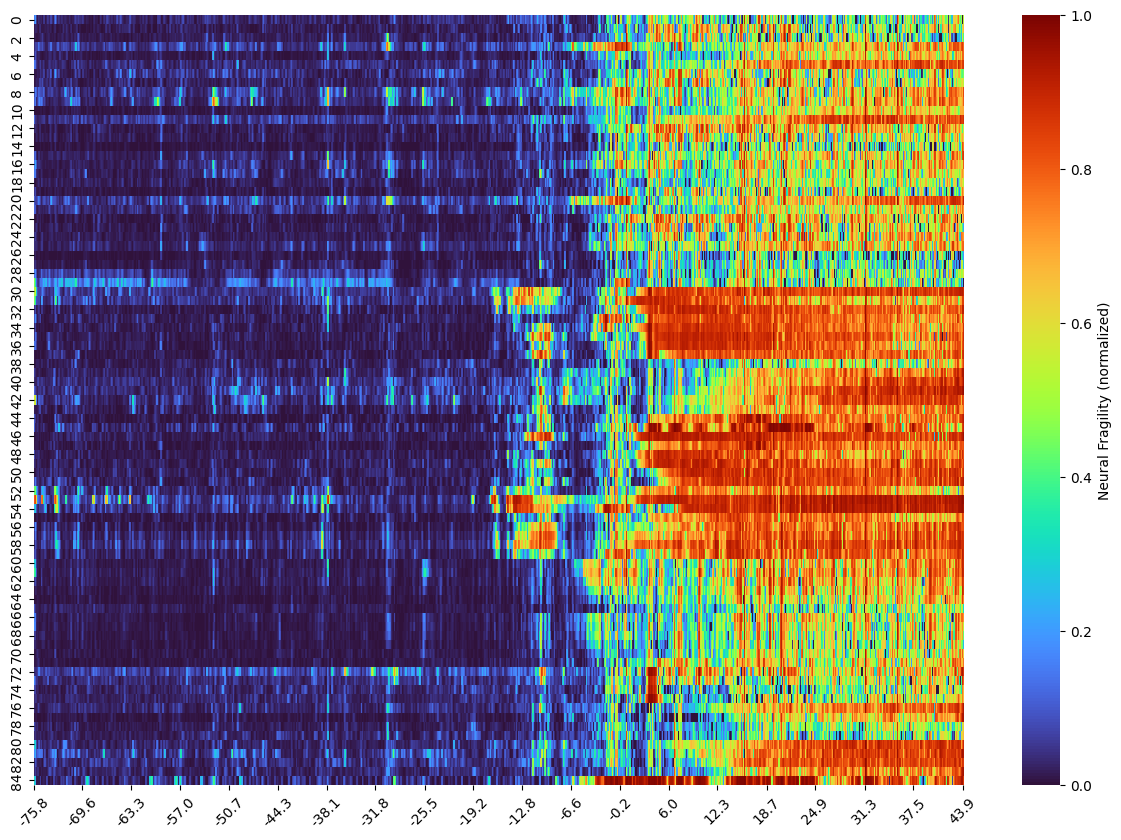

In [ ]:
import numpy as np
from tqdm import tqdm
from sreedhar_alg import *

# 注意: ユーザー環境ですでに定義されていると仮定します
# def neural_fragility_inf(A, k):
#     ...

def compute_and_plot_fragility(A_matrices):
    """
    既存の neural_fragility_inf 関数を使用してFragilityマップを計算し、表示します。
    
    Parameters:
    -----------
    A_matrices : np.ndarray
        (n_windows, n_channels, n_channels) の形状を持つ推定されたA行列群
    channel_names : list of str
        チャンネル名のリスト
    times : np.ndarray
        各ウィンドウに対応する時刻の配列
    onset_time : float
        発作開始時刻 (プロットのX軸調整用)
    """
    n_windows, n_channels, _ = A_matrices.shape
    
    # --- 1. Raw Fragility の計算 ---
    # 結果を格納する配列 (チャンネル x 時間)
    raw_fragility = np.zeros((n_channels, n_windows))
    
    print(f"Calculating Neural Fragility for {n_channels} channels x {n_windows} windows...")
    
    # 時間ウィンドウごとのループ
    for t in tqdm(range(n_windows)):
        A = A_matrices[t]
        
        # チャンネル(列)ごとのループ
        for k in range(n_channels):
            # 論文の手法に基づき、行列Aのk列目に対する最小摂動ノルムを計算
            # 既存の関数を使用: neural_fragility_inf(A, column_index)
            val, _ , _ = neural_fragility_inf(A, k, print_progress=False)
            raw_fragility[k, t] = val

    # --- 2. 正規化 (Normalization) ---
    # 論文記述: "Values at each window of time were normalized across electrodes... range from 0 up to at most 1"
    # 時間軸(列)ごとに、チャンネル方向でMin-Max正規化を行います
    normalized_fragility = np.zeros_like(raw_fragility)
    
    # 各時間ステップごとに処理
    # min_vals = np.min(raw_fragility, axis=0)
    max_vals = np.max(raw_fragility, axis=0)
    # ranges = max_vals - min_vals
    
    # ゼロ除算を防ぐ処理
    # ranges[ranges == 0] = 1.0
    # print(len(ranges == 0))
    
    # ブロードキャストを使用して一括正規化
    normalized_fragility = (max_vals - raw_fragility) / (max_vals + 1e-9)
    return raw_fragility, normalized_fragility

# --- 実行 ---
# A_mats: 前のステップで計算したA行列
raw_fragility, normalized_fragility = compute_and_plot_fragility(
    A_mats, 
)

n_windows, n_channels, _ = A_mats.shape

channel_names = raw_cropped.ch_names
times = window_times
onset_time = seizure_onset_time

# --- 3. ヒートマップの表示 ---
plt.figure(figsize=(15, 10))

# 論文では "Turbo" カラーマップが使用されています
ax = sns.heatmap(normalized_fragility, 
                    cmap='turbo', 
                    vmin=0.0, vmax=1.0,
                    cbar_kws={'label': 'Neural Fragility (normalized)'})

# X軸ラベルの調整 (Onsetを0とした相対時間)
# 表示するラベルの数を制限して見やすくする
n_ticks = 20
tick_indices = np.linspace(0, n_windows - 1, n_ticks, dtype=int)
tick_labels = [f"{times[i] - onset_time:.1f}" for i in tick_indices]

ax.set_xticks(tick_indices)
ax.set_xticklabels(tick_labels, rotation=45)

# Y軸ラベル (チャンネル名)
# ax.set_yticklabels(channel_names, rotation=0, fontsize=8)

# タイトルと軸ラベル
plt.title("Neural Fragility Heatmap")
plt.xlabel("Time relative to Seizure Onset (s)")
plt.ylabel("Channels")

# Onsetラインの描画 (time=0 の位置)
# times配列の中で onset_time に最も近いインデックスを探す
onset_idx = np.argmin(np.abs(times - onset_time))
plt.axvline(x=onset_idx, color='white', linestyle='--', linewidth=2, label='Seizure Onset')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [29]:
# raw_fragility と normalized_fragility を pickle ファイルなどに保存して後で利用できるようにする

with open('fragility_data_g11_g12_removed.pkl', 'wb') as f:
    pickle.dump({
        'raw_fragility': raw_fragility,
        'normalized_fragility': normalized_fragility,
        'channel_names': raw_cropped.ch_names,
        'window_times': window_times,
        'seizure_onset_time': seizure_onset_time
    }, f)


In [7]:
import pickle

# 保存したデータは後で読み込んで解析や可視化に利用できます
with open('fragility_data_g11_g12_removed.pkl', 'rb') as f:
    fragility_data = pickle.load(f)
raw_fragility = fragility_data['raw_fragility']
normalized_fragility = fragility_data['normalized_fragility']
channel_names = fragility_data['channel_names']
times = fragility_data['window_times']
onset_time = fragility_data['seizure_onset_time']

/var/folders/g1/zjq4txwj7q743_zypqwzpz3c0000gn/T/ipykernel_62425/427904785.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


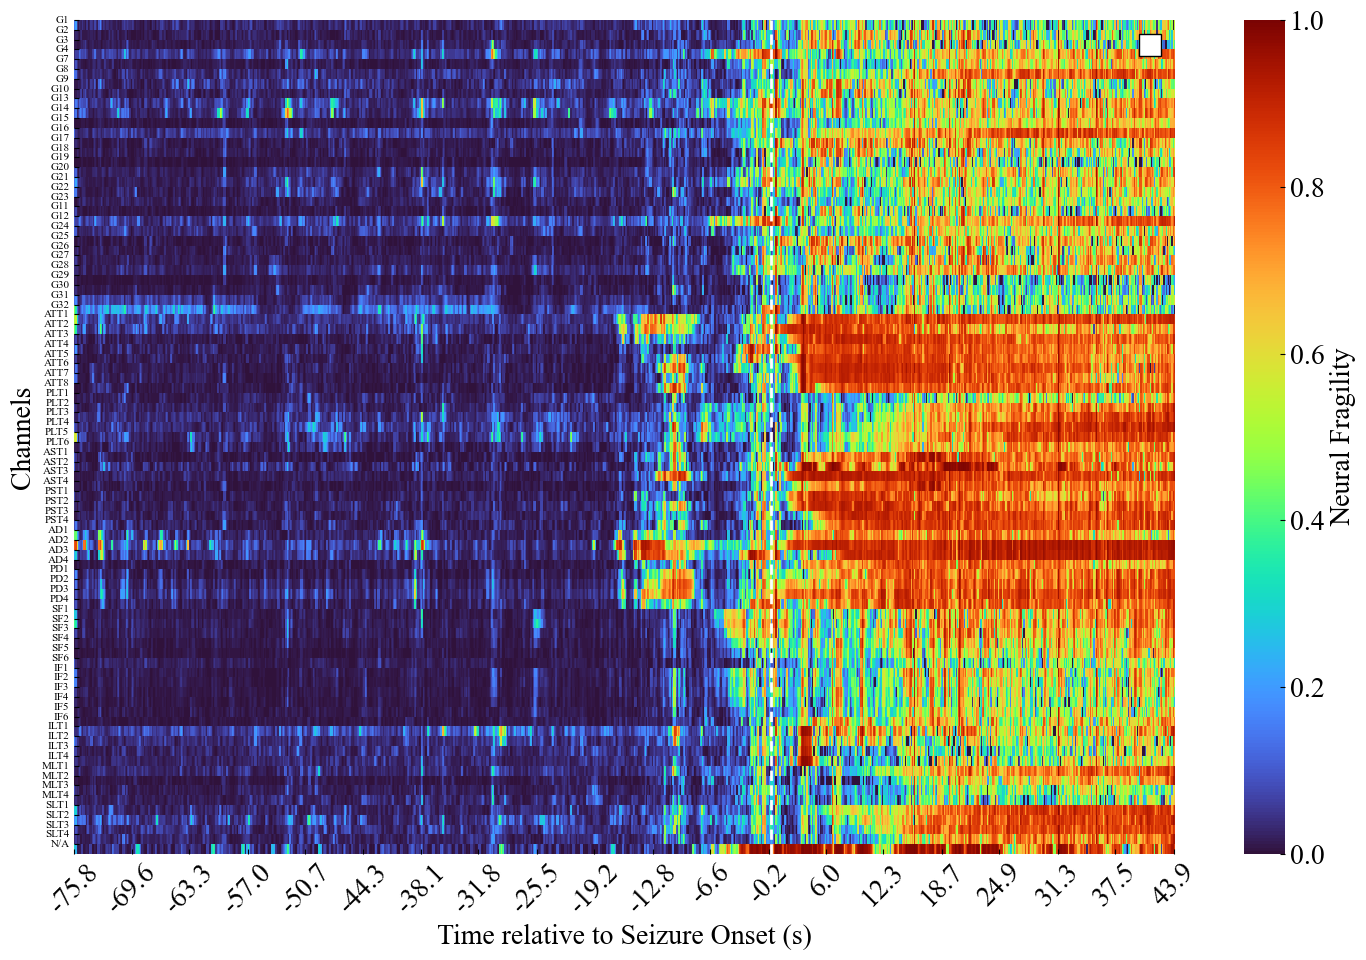

In [9]:
n_channels, n_windows = normalized_fragility.shape

# channel_names = raw_cropped.ch_names
# times = window_times
# onset_time = seizure_onset_time

# # 36, 37番目を削除
# print(f"Removing channels: {channel_names[36]}, {channel_names[37]}")
# channel_names.pop(37)
# channel_names.pop(36)
# normalized_fragility = np.delete(normalized_fragility, [36, 37], axis=0)

# --- 3. ヒートマップの表示 ---
plt.figure(figsize=(15, 10))

# 論文では "Turbo" カラーマップが使用されています
ax = sns.heatmap(normalized_fragility, 
                    cmap='turbo', 
                    vmin=0.0, vmax=1.0,
                    cbar_kws={'label': 'Neural Fragility'})

# X軸ラベルの調整 (Onsetを0とした相対時間)
# 表示するラベルの数を制限して見やすくする
# X軸ラベルの調整 (Onsetを0とした相対時間)
n_ticks = 20
tick_indices = np.linspace(0, n_windows - 1, n_ticks, dtype=int)
# print(tick_indices)
# print(n_windows)
tick_labels = [f"{times[i] - onset_time:.1f}" for i in tick_indices]

# # ★ ここが重要：+0.5 する
ax.set_xticks(tick_indices)
ax.set_xticklabels(tick_labels, rotation=45)


# Y軸ラベル (チャンネル名)
ax.set_yticks(np.arange(len(channel_names)))  # 0から86までの位置を確保
ax.set_yticklabels(channel_names, rotation=0, fontsize=8)

# タイトルと軸ラベル
# plt.title("Neural Fragility Heatmap")
plt.xlabel("Time relative to Seizure Onset (s)")
plt.ylabel("Channels")

# Onsetラインの描画 (time=0 の位置)
# times配列の中で onset_time に最も近いインデックスを探す
onset_idx = np.argmin(np.abs(times - onset_time))
plt.axvline(x=onset_idx, color='white', linestyle='--', linewidth=2)
plt.legend(loc='upper right')

plt.tight_layout()

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 20  # 適当に必要なサイズに
plt.rcParams['xtick.direction'] = 'in'  # in or out
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.xmargin'] = 0.01
plt.rcParams['axes.ymargin'] = 0.01
plt.rcParams["legend.fancybox"] = False  # 丸角OFF
plt.rcParams["legend.framealpha"] = 1  # 透明度の指定、0で塗りつぶしなし
plt.rcParams["legend.edgecolor"] = 'black'  # edgeの色を変更
plt.rcParams['mathtext.default']= 'default'

save_openneuro_heatmap_tikz(
    normalized_fragility,
    times,
    onset_time,
    channel_names,
    OPENNEURO_TIKZ_DIR / 'openNeuro_proposed.tex',
    OPENNEURO_ASSET_DIR / 'openNeuro_proposed.png',
    colorbar_label='Neural Fragility',
)
# plt.show()
plt.show()


Calculating Neural Fragility for 85 channels x 959 windows...


100%|██████████| 959/959 [24:56<00:00,  1.56s/it]


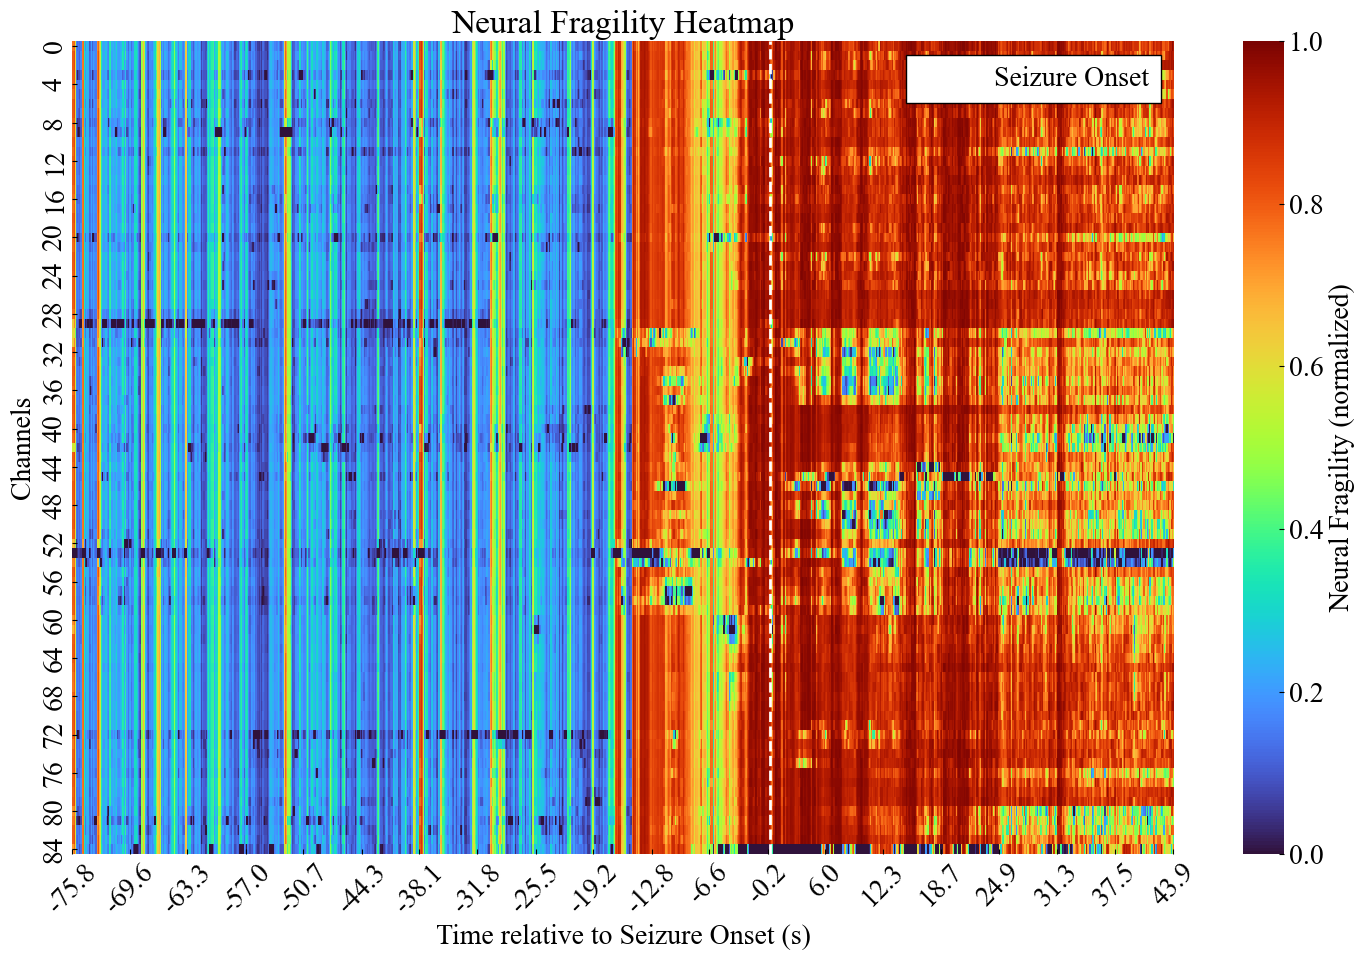

In [21]:
import numpy as np
from tqdm import tqdm
from sreedhar_alg import *

# 注意: ユーザー環境ですでに定義されていると仮定します
# def neural_fragility_inf(A, k):
#     ...

def run_grid_search(A, k, num_points):
    thetas = np.linspace(0, np.pi, num_points)
    max_val = -1.0
    
    for t in thetas:
        val = calculate_inf_sigma2_single(A, k, t)
        if val > max_val:
            max_val = val
    
    return max_val

def compute_and_plot_fragility(A_matrices):
    """
    既存の neural_fragility_inf 関数を使用してFragilityマップを計算し、表示します。
    
    Parameters:
    -----------
    A_matrices : np.ndarray
        (n_windows, n_channels, n_channels) の形状を持つ推定されたA行列群
    channel_names : list of str
        チャンネル名のリスト
    times : np.ndarray
        各ウィンドウに対応する時刻の配列
    onset_time : float
        発作開始時刻 (プロットのX軸調整用)
    """
    n_windows, n_channels, _ = A_matrices.shape
    
    # --- 1. Raw Fragility の計算 ---
    # 結果を格納する配列 (チャンネル x 時間)
    raw_fragility = np.zeros((n_channels, n_windows))
    
    print(f"Calculating Neural Fragility for {n_channels} channels x {n_windows} windows...")
    
    # 時間ウィンドウごとのループ
    for t in tqdm(range(n_windows)):
        A = A_matrices[t]
        
        # チャンネル(列)ごとのループ
        for k in range(n_channels):
            # 論文の手法に基づき、行列Aのk列目に対する最小摂動ノルムを計算
            # 既存の関数を使用: neural_fragility_inf(A, column_index)
            # val, _ , _ = neural_fragility_inf(A, k, print_progress=False)
            val = run_grid_search(A, k, num_points=100)
            raw_fragility[k, t] = val
        
        if t % 100 == 0:
            with open(f'fragility_temp_window_{t}.pkl', 'wb') as f:
                pickle.dump(raw_fragility, f)

    with open(f'fragility_temp_window_grid_search_1000.pkl', 'wb') as f:
            pickle.dump(raw_fragility, f)
    # --- 2. 正規化 (Normalization) ---
    # 論文記述: "Values at each window of time were normalized across electrodes... range from 0 up to at most 1"
    # 時間軸(列)ごとに、チャンネル方向でMin-Max正規化を行います
    normalized_fragility = np.zeros_like(raw_fragility)
    
    # 各時間ステップごとに処理
    # min_vals = np.min(raw_fragility, axis=0)
    max_vals = np.max(raw_fragility, axis=0)
    # ranges = max_vals - min_vals
    
    # ゼロ除算を防ぐ処理
    # ranges[ranges == 0] = 1.0
    # print(len(ranges == 0))
    
    # ブロードキャストを使用して一括正規化
    normalized_fragility = (max_vals - raw_fragility) / (max_vals + 1e-14)
    return raw_fragility, normalized_fragility

# --- 実行 ---
# A_mats: 前のステップで計算したA行列
raw_fragility, normalized_fragility = compute_and_plot_fragility(
    A_mats, 
)

n_windows, n_channels, _ = A_mats.shape

channel_names = raw_cropped.ch_names
times = window_times
onset_time = seizure_onset_time

# --- 3. ヒートマップの表示 ---
plt.figure(figsize=(15, 10))

# 論文では "Turbo" カラーマップが使用されています
ax = sns.heatmap(normalized_fragility, 
                    cmap='turbo', 
                    vmin=0.0, vmax=1.0,
                    cbar_kws={'label': 'Neural Fragility (normalized)'})

# X軸ラベルの調整 (Onsetを0とした相対時間)
# 表示するラベルの数を制限して見やすくする
n_ticks = 20
tick_indices = np.linspace(0, n_windows - 1, n_ticks, dtype=int)
tick_labels = [f"{times[i] - onset_time:.1f}" for i in tick_indices]

ax.set_xticks(tick_indices)
ax.set_xticklabels(tick_labels, rotation=45)

# Y軸ラベル (チャンネル名)
# ax.set_yticklabels(channel_names, rotation=0, fontsize=8)

# タイトルと軸ラベル
plt.title("Neural Fragility Heatmap")
plt.xlabel("Time relative to Seizure Onset (s)")
plt.ylabel("Channels")

# Onsetラインの描画 (time=0 の位置)
# times配列の中で onset_time に最も近いインデックスを探す
onset_idx = np.argmin(np.abs(times - onset_time))
plt.axvline(x=onset_idx, color='white', linestyle='--', linewidth=2, label='Seizure Onset')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [22]:
# raw_fragility と normalized_fragility を pickle ファイルなどに保存して後で利用できるようにする

with open('grid_search_fragility_data_g11_g12_removed.pkl', 'wb') as f:
    pickle.dump({
        'raw_fragility': raw_fragility,
        'normalized_fragility': normalized_fragility,
        'channel_names': raw_cropped.ch_names,
        'window_times': window_times,
        'seizure_onset_time': seizure_onset_time
    }, f)

In [12]:
raw_fragility.shape

(85, 959)

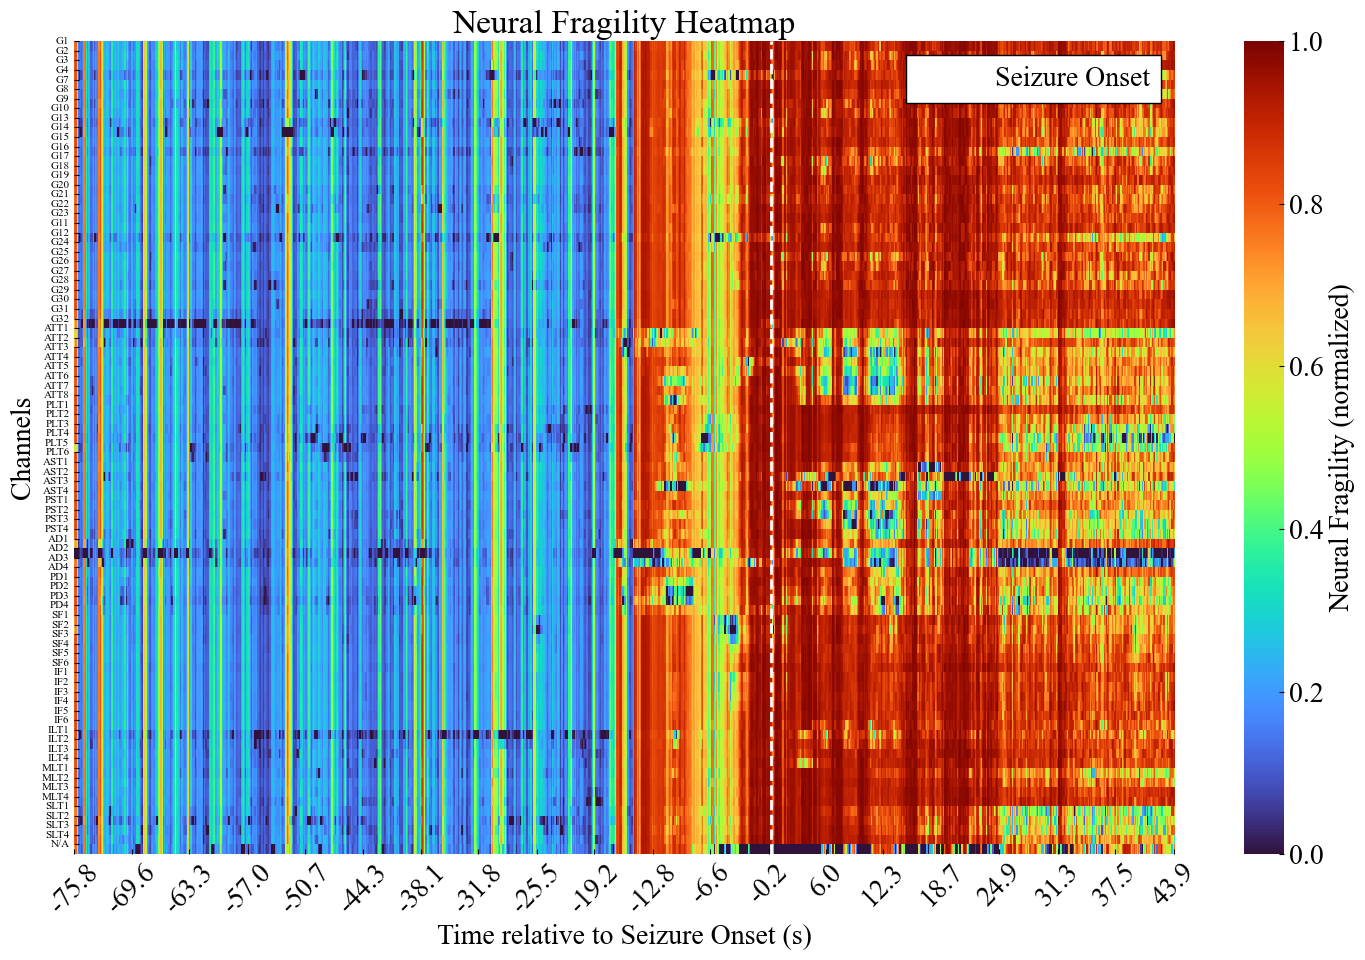

In [24]:
max_vals = np.max(raw_fragility, axis=0)
normalized_fragility2 = (max_vals - raw_fragility) / (max_vals + 1e-14)


n_windows, n_channels, _ = A_mats.shape

channel_names = raw_cropped.ch_names
times = window_times
onset_time = seizure_onset_time

# --- 3. ヒートマップの表示 ---
plt.figure(figsize=(15, 10))

# 論文では "Turbo" カラーマップが使用されています
ax = sns.heatmap(normalized_fragility2, 
                    cmap='turbo', 
                    vmin=0.0, vmax=1.0,
                    cbar_kws={'label': 'Neural Fragility (normalized)'})

# X軸ラベルの調整 (Onsetを0とした相対時間)
# 表示するラベルの数を制限して見やすくする
n_ticks = 20
tick_indices = np.linspace(0, n_windows - 1, n_ticks, dtype=int)
tick_labels = [f"{times[i] - onset_time:.1f}" for i in tick_indices]

ax.set_xticks(tick_indices)
ax.set_xticklabels(tick_labels, rotation=45)

# Y軸ラベル (チャンネル名)
ax.set_yticks(np.arange(len(channel_names)))  # 0から86までの位置を確保
ax.set_yticklabels(channel_names, rotation=0, fontsize=8)

# タイトルと軸ラベル
plt.title("Neural Fragility Heatmap")
plt.xlabel("Time relative to Seizure Onset (s)")
plt.ylabel("Channels")

# Onsetラインの描画 (time=0 の位置)
# times配列の中で onset_time に最も近いインデックスを探す
onset_idx = np.argmin(np.abs(times - onset_time))
plt.axvline(x=onset_idx, color='white', linestyle='--', linewidth=2, label='Seizure Onset')
plt.legend(loc='upper right')

plt.tight_layout()

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 20  # 適当に必要なサイズに
plt.rcParams['xtick.direction'] = 'in'  # in or out
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.xmargin'] = 0.01
plt.rcParams['axes.ymargin'] = 0.01
plt.rcParams["legend.fancybox"] = False  # 丸角OFF
plt.rcParams["legend.framealpha"] = 1  # 透明度の指定、0で塗りつぶしなし
plt.rcParams["legend.edgecolor"] = 'black'  # edgeの色を変更
plt.rcParams['mathtext.default']= 'default'

save_openneuro_heatmap_tikz(
    normalized_fragility2,
    times,
    onset_time,
    channel_names,
    OPENNEURO_TIKZ_DIR / 'openNeuro_grid.tex',
    OPENNEURO_ASSET_DIR / 'openNeuro_grid.png',
    colorbar_label='Neural Fragility (normalized)',
    include_title=True,
)
# plt.show()
plt.show()


In [13]:
test = np.array([[1,2,3],[4,5,6]])
test.shape

(2, 3)

In [16]:
m = np.max(test, axis=0)
normalized = (m - test) / (m + 1e-14)

In [17]:
normalized

array([[0.75, 0.6 , 0.5 ],
       [0.  , 0.  , 0.  ]])

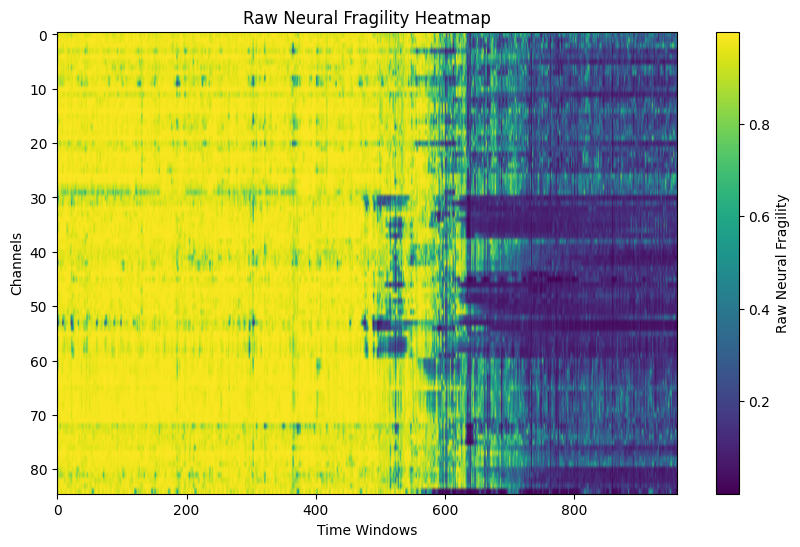

In [13]:
# raw_fragility を可視化
plt.figure(figsize=(10, 6))
plt.imshow(raw_fragility, aspect='auto', cmap='viridis')
plt.colorbar(label='Raw Neural Fragility')
plt.title("Raw Neural Fragility Heatmap")
plt.xlabel("Time Windows")
plt.ylabel("Channels")
plt.show()

Estimating linear models for 959 windows...
Regularization lambda: 0.0


100%|██████████| 959/959 [00:00<00:00, 1365.46it/s]


Stable A matrices: 12 / 959 (1.25%)


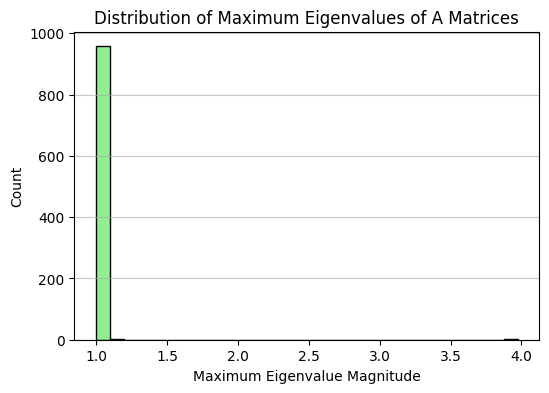

In [14]:
# ridge回帰 ありなしの比較
# A_mats_ridge = estimate_linear_models(windows, l2_lambda=0.0001)
A_mats_without_ridge = estimate_linear_models(windows, l2_lambda=0.0)

# 各行列が安定であるかどうかを判定する関数
def is_stable(A):
    """行列Aが安定かどうかを判定する関数。すべての固有値の絶対値が1以下であれば安定とみなす。"""
    eigenvalues = np.linalg.eigvals(A)
    return np.all(np.abs(eigenvalues) <= 1.0)

# A_mats_without_ridge が安定であるかどうかを確認
stability_results = [is_stable(A) for A in A_mats_without_ridge]
n_stable = sum(stability_results)
n_total = len(A_mats_without_ridge)
print(f"Stable A matrices: {n_stable} / {n_total} ({(n_stable / n_total) * 100:.2f}%)")

# 最大固有値の分布を見る
max_eigenvalues = [max(np.abs(np.linalg.eigvals(A))) for A in A_mats_without_ridge]
plt.figure(figsize=(6,4))
plt.hist(max_eigenvalues, bins=30, color='lightgreen', edgecolor='black')
plt.title("Distribution of Maximum Eigenvalues of A Matrices")
plt.xlabel("Maximum Eigenvalue Magnitude")
plt.ylabel("Count")
plt.grid(axis='y', alpha=0.7)
plt.show()

Estimating noise covariances for 959 windows...


100%|██████████| 959/959 [00:00<00:00, 6361.91it/s]

Estimated Sigma matrices: 959
First Sigma matrix:
[[ 3.73826414e-09  1.70080321e-09 -1.18959112e-09 ... -9.92168249e-11
   1.74997356e-11 -1.92845923e-09]
 [ 1.70080321e-09  2.75962461e-09  1.05242095e-09 ...  1.79922739e-10
   4.16879408e-10  1.69198596e-09]
 [-1.18959112e-09  1.05242095e-09  3.80051094e-09 ... -4.68255505e-10
  -1.30975799e-10  1.62595910e-09]
 ...
 [-9.92168249e-11  1.79922739e-10 -4.68255505e-10 ...  5.54575472e-09
   2.08118059e-09  2.30301170e-09]
 [ 1.74997356e-11  4.16879408e-10 -1.30975799e-10 ...  2.08118059e-09
   2.69577689e-09  1.77069461e-09]
 [-1.92845923e-09  1.69198596e-09  1.62595910e-09 ...  2.30301170e-09
   1.77069461e-09  2.95394788e-08]]


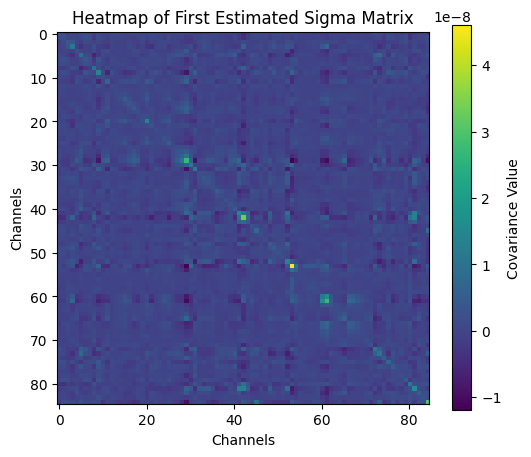

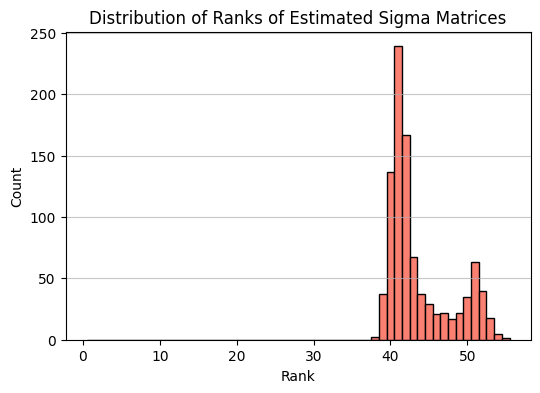

In [19]:
# A_matsに対して、実データで最尤推定したときの、Sigmaを計算する
def estimate_noise_covariances(windows, A_matrices):
    """
    各ウィンドウについて、線形モデル x(t+1) = Ax(t) のノイズ共分散行列 Σ を推定します。
    
    Parameters:
    -----------
    windows : np.ndarray
        形状 (n_windows, n_channels, n_samples) のデータ
    A_matrices : np.ndarray
        形状 (n_windows, n_channels, n_channels) の推定モデル
        
    Returns:
    --------
    Sigma_matrices : list of np.ndarray
        推定されたΣ行列のリスト。各要素は形状 (n_channels, n_channels)
    """
    n_windows, n_channels, n_samples = windows.shape
    
    Sigma_matrices = []
    
    print(f"Estimating noise covariances for {n_windows} windows...")
    
    for i in tqdm(range(n_windows)):
        W = windows[i]
        A = A_matrices[i]
        
        # X(t) と X(t+1) の取得
        X_t = W[:, :-1]
        X_t1 = W[:, 1:]
        
        # 予測誤差の計算
        residuals = X_t1 - (A @ X_t)
        
        # ノイズ共分散行列 Σ の推定
        Sigma_hat = (residuals @ residuals.T) / (n_samples - 1)
        Sigma_matrices.append(Sigma_hat)
    
    return Sigma_matrices

# --- 実行 ---
Sigma_mats = estimate_noise_covariances(windows, A_mats)
print(f"Estimated Sigma matrices: {len(Sigma_mats)}")

# 適当に最初のΣ行列を表示してみる
print("First Sigma matrix:")
print(Sigma_mats[0])

# 最初のΣ行列のヒートマップを表示
plt.figure(figsize=(6,5))
plt.imshow(Sigma_mats[0], cmap='viridis')
plt.colorbar(label='Covariance Value')
plt.title("Heatmap of First Estimated Sigma Matrix")
plt.xlabel("Channels")
plt.ylabel("Channels")
plt.show()

# 特異値分解 (SVD) を用いて、各Σ行列のランクを調べる
ranks = []
for Sigma in Sigma_mats:
    u, s, vh = np.linalg.svd(Sigma)
    rank = np.sum(s > 1e-10)  # 数値的にゼロでない特異値の数をカウント
    ranks.append(rank)

# ランクの分布をヒストグラムで表示
plt.figure(figsize=(6,4))
plt.hist(ranks, bins=range(1, max(ranks)+2), color='salmon', edgecolor='black', align='left')
plt.title("Distribution of Ranks of Estimated Sigma Matrices")
plt.xlabel("Rank")
plt.ylabel("Count")
plt.grid(axis='y', alpha=0.7)
plt.show()